<a href="https://colab.research.google.com/github/robertbarcik/genai-in-python-tutorial/blob/main/2_basic_project_examples/2_basic_project_examples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seven Small Apps, One API Call

Every app in this notebook is built on the same move: **send some text to the model, get some text back**. You will see that move seven times, each time pointed at a different job: a photo, a recording, a messy email, a bedtime story, a database, a support ticket.

Run the setup once, then jump to any section. Each section is independent, and each ends with a small "your turn".

## Setup

Install the library, connect the client, and make sure the sample data is here. Run this cell once.

In [1]:
%pip install -q openai==3.13.0 pandas==2.2.2 pydantic==2.12.3 pillow==11.3.0   # Colab installs here; locally, `pip install -r requirements.txt` already covers it

import os
from openai import OpenAI

# Your key, looked up in this order: Colab secret -> environment variable -> a prompt.
try:
    from google.colab import userdata
    api_key = userdata.get("OPENAI_API_KEY")
except Exception:
    api_key = os.environ.get("OPENAI_API_KEY")
if not api_key:
    from getpass import getpass
    api_key = getpass("OpenAI API key: ")

client = OpenAI(api_key=api_key)
MODEL = "gpt-5.6-luna"   # small, cheap model of the current generation (~$0.20 in / $1.20 out per 1M tokens)

# Data files: next to this notebook if you downloaded the course folder; fetched from GitHub otherwise (Colab).
import pathlib, urllib.request
RAW = "https://raw.githubusercontent.com/robertbarcik/genai-in-python-tutorial/main/2_basic_project_examples/"
for name in ['data/sunflower.jpg', 'data/sample_lecture_clip.mp3', 'data/tickets.csv', 'data/technicians.csv', 'data/support_emails.txt', 'data/kb_ticket_notes.txt']:
    if not pathlib.Path(name).exists():
        pathlib.Path(name).parent.mkdir(parents=True, exist_ok=True)
        urllib.request.urlretrieve(RAW + name, name)

print("Ready. Model:", MODEL)

Note: you may need to restart the kernel to use updated packages.
Ready. Model: gpt-5.6-luna


# 1. One Call Is All You Need

Here is the engine, stripped to its simplest form, plus the two knobs you will reach for most: giving the model a **role**, and **streaming** the answer as it types.

### The one thing you change

A task in plain English. Change it, re-run the cells below, and the app does something else entirely.

In [2]:
task = "Draft a short, friendly reply to a customer who says their password reset email never arrived."

### The one call

Send text in, get text out. Everything else in this notebook is a variation on these four lines.

In [3]:
reply = client.responses.create(
    model=MODEL,
    input=task,
).output_text

print(reply)

Hi [Customer Name],

Sorry the password reset email hasn’t arrived! Please check your spam or junk folder and confirm that you entered the email address associated with your account. You can also try requesting a new reset email.

If it still doesn’t come through, let us know and we’ll be happy to help.

Best,  
[Your Name/Support Team]


### Give it a role

A **developer message** is your instruction to the model that arrives before the user's request: who it is, how it should behave. Same call, same task, different voice.

In [4]:
persona = "You are a blunt, no-nonsense senior sysadmin. You value brevity over pleasantries."

reply_blunt = client.responses.create(
    model=MODEL,
    input=[
        {"role": "developer", "content": persona},
        {"role": "user", "content": task},
    ],
).output_text

print(reply_blunt)

Hi [Name],

Sorry you haven’t received the password reset email. Please check your spam or junk folder and confirm that we have the correct email address on file. If it’s still missing, let us know and we’ll help you reset your password another way.

Best,  
[Your Name]


### Watch it type

**Streaming** gives you the answer piece by piece instead of all at once. That is how chat apps feel fast: the first words appear immediately.

In [5]:
with client.responses.stream(model=MODEL, input=task) as stream:
    for event in stream:
        if event.type == "response.output_text.delta":
            print(event.delta, end="", flush=True)

Hi [Customer Name],

Sorry about that! Please check your spam or junk folder, as the reset email may have been filtered there. You can also request a new reset link and confirm you’re using the email address associated with your account.

If it still doesn’t arrive, let us know and we’ll be happy to help.

### 🔍 What just happened?

Three calls, one shape: `client.responses.create(model=..., input=...)`. The role changed the voice, streaming changed the delivery, and the model never saw anything but text. Keep that shape in mind; the next six sections only change what goes into `input`.

### 🎯 Your turn

Change `task` and `persona` above and re-run the three cells.

# 2. Plant ID

Point the app at a photo; it looks at the pixels and names the plant. Same call as before, with an image next to the text.

### The photo you identify

A sunflower from the course data folder. Any public image URL works too, so change `photo` and re-run.

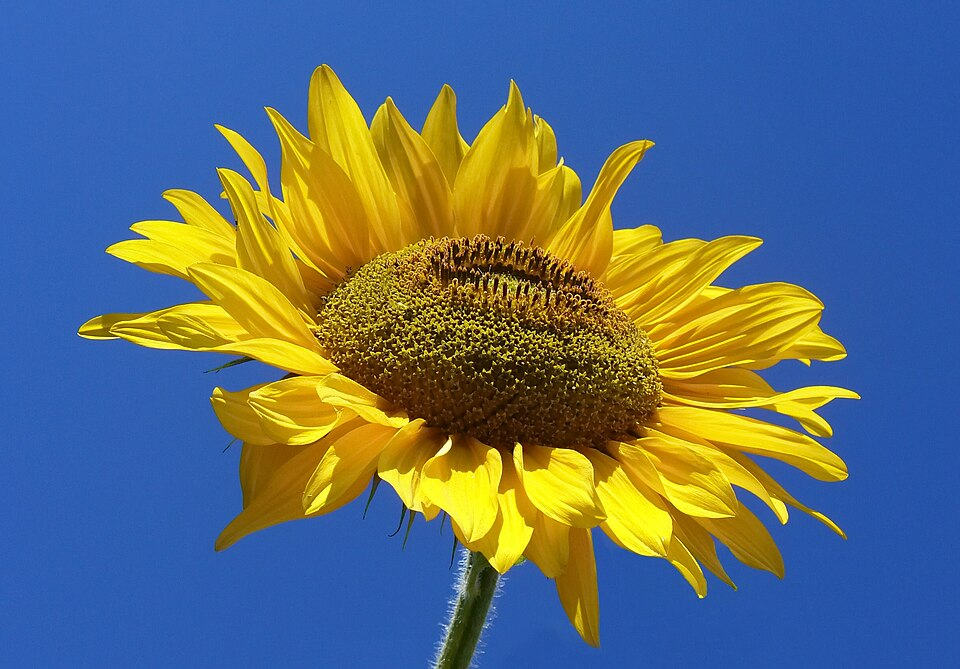

In [6]:
import base64
from IPython.display import Image, display

photo = "data/sunflower.jpg"          # or a URL like "https://.../some_plant.jpg"
display(Image(photo, width=360))

# The API takes an image as a URL, or as the file's bytes encoded in base64. Handle both.
if photo.startswith("http"):
    image_url = photo
else:
    with open(photo, "rb") as f:
        image_url = "data:image/jpeg;base64," + base64.b64encode(f.read()).decode()

### The one call

The user message now has two parts: a text part and an image part. That is the whole difference.

In [7]:
plant = client.responses.create(
    model=MODEL,
    input=[{
        "role": "user",
        "content": [
            {"type": "input_text", "text": "Identify the plant in this photo. Reply with just the common name."},
            {"type": "input_image", "image_url": image_url},
        ],
    }],
).output_text

print(plant)

Sunflower


### Chain a second call

The answer is just a string, so you can put it straight into the next question. Two calls, one small app.

In [8]:
tips = client.responses.create(
    model=MODEL,
    input=f"Give three short care tips for a {plant}, one line each.",
).output_text

print(f"Care tips for your {plant}:\n{tips}")

Care tips for your Sunflower:
- Give sunflowers 6–8 hours of direct sunlight daily.  
- Water deeply when the top inch of soil feels dry.  
- Support tall stems and protect them from strong winds.


### 🔍 What just happened?

The model read the pixels and answered in one word. Nothing about "vision" changed the call; the image is just another item in `content`. The second call shows the pattern behind most real apps: the output of one call becomes the input of the next.

### 🎯 Your turn

Set `photo` to any plant photo URL and run the section again. Then ask for something else in the second call, for example "Is it safe for cats?".

# 3. Knowledge From a Recording

Hand the app a recording; it turns speech into text, then turns that text into clean notes. The same two calls work on a lecture, a meeting, or a podcast.

### The clip you use

A short mock lecture snippet, filler words and all. Point `AUDIO_PATH` at your own audio or video file to use it on real content.

In [9]:
from IPython.display import Audio, display

AUDIO_PATH = "data/sample_lecture_clip.mp3"
display(Audio(AUDIO_PATH))

### The one call

A different endpoint this time, because the input is sound, not text: `client.audio.transcriptions`. Send the file, get the spoken words back.

In [10]:
import time

t0 = time.time()
with open(AUDIO_PATH, "rb") as f:
    transcript = client.audio.transcriptions.create(model="gpt-transcribe", file=f).text
print(f"Transcribed in {time.time() - t0:.1f} s\n")
print(transcript)

Transcribed in 1.9 s

Okay, so today I want to talk about, you know, how spaced repetition works for learning. Basically, the idea is you review material right before you're about to forget it. So, like, instead of cramming everything the night before, you spread your reviews out over days and weeks. And every time you successfully recall something, the gap before the next review gets longer. This is kind of the secret behind apps like Anki and Duolingo. So yeah, that's spaced repetition in a nutshell.


### Turn it into notes

Now we are back to text, so the familiar call takes over. The developer message says what "clean" means.

In [11]:
notes = client.responses.create(
    model=MODEL,
    input=[
        {"role": "developer", "content":
            "Clean this raw speech transcript into short, clear speaking notes. "
            "Remove filler words, fix punctuation, keep the meaning exactly the same."},
        {"role": "user", "content": transcript},
    ],
).output_text

print(notes)

- **Spaced repetition** involves reviewing material just before you are likely to forget it.
- Instead of cramming the night before, spread reviews across days and weeks.
- Each successful recall increases the interval before the next review.
- This approach powers apps such as Anki and Duolingo.
- In short, that is spaced repetition.


### 🔍 What just happened?

Two models, two jobs: a speech model turned sound into words, a text model turned words into notes. The hand-off between them is a plain Python string. A video file works the same way once you pull out its audio track (for example with `moviepy`).

### 🎯 Your turn

Swap in your own recording. Then change the developer message to "Summarize this in three bullet points" and compare.

# 4. Messy Text In, JSON Out

Support tickets, emails, and reports arrive as free-form text. You describe the **shape** you want back, and the model fills it in. No regex, no manual parsing.

### The shape

A Pydantic model is a Python class that describes fields and their types. It is the only thing that changes when you extract something else.

In [12]:
from enum import Enum
from pydantic import BaseModel


class Urgency(str, Enum):
    low = "low"
    medium = "medium"
    high = "high"
    critical = "critical"


class SupportTicket(BaseModel):
    user_name: str
    department: str
    issue_summary: str
    urgency: Urgency
    category: str

### The messy text

Three real-looking emails from the data folder, separated by a line of dashes. Here is the first one.

In [13]:
emails = open("data/support_emails.txt").read().split("-----")
emails = [e.strip() for e in emails if e.strip()]

print(f"{len(emails)} emails loaded. The first one:\n")
print(emails[0])

3 emails loaded. The first one:

From: jennifer.martinez@company.com
Subject: Urgent - Cannot Access Email

Hi IT Support,

I'm Jennifer Martinez from the Sales department. Since this morning I can't
log into Outlook, it just keeps saying my password is wrong even though I
haven't changed it. I have a client call in an hour and I need my inbox.
Please help ASAP!

Thanks,
Jennifer


### The one call

`responses.parse` with `text_format=SupportTicket` tells the model the exact shape; `output_parsed` gives you back a real Python object, already validated.

In [14]:
ticket = client.responses.parse(
    model=MODEL,
    input=f"Extract the support ticket details from this email:\n\n{emails[0]}",
    text_format=SupportTicket,
).output_parsed

print(ticket)
print("\nUrgency as a plain value:", ticket.urgency.value)

user_name='Jennifer Martinez' department='Sales' issue_summary='Unable to log into Outlook; the system repeatedly reports an incorrect password despite no password change. Needs email access before a client call in one hour.' urgency=<Urgency.high: 'high'> category='Email access / password authentication'

Urgency as a plain value: high


### Now all of them

Loop the same call over every email and drop the results into a table, sorted so the most urgent one is on top. This is the moment a pile of emails becomes a queue.

In [15]:
import pandas as pd

tickets = [
    client.responses.parse(
        model=MODEL,
        input=f"Extract the support ticket details from this email:\n\n{email}",
        text_format=SupportTicket,
    ).output_parsed
    for email in emails
]

order = ["critical", "high", "medium", "low"]
table = pd.DataFrame([t.model_dump() for t in tickets])
table["urgency"] = table["urgency"].map(lambda u: u.value)
table.sort_values("urgency", key=lambda col: col.map(order.index))

,user_name,department,issue_summary,urgency,category
2,Priya Nair,Finance,Production payment gateway outage: since 09:40...,critical,Payment gateway outage
0,Jennifer Martinez,Sales,Unable to log into Outlook because the system ...,high,Email access
1,Marcus,Engineering,Laptop screen flickers and intermittently goes...,medium,Hardware


### 🔍 What just happened?

You never told the model "return JSON" or "use these field names". The Pydantic class did that, and the API guarantees the answer fits it. From here, routing tickets is ordinary Python: `if ticket.urgency == Urgency.critical: page_someone()`.

### 🎯 Your turn

Add a field to `SupportTicket` (for example `needs_callback: bool`) and re-run the two calls. Then paste your own messy text into the data file.

# 5. Fairytale Studio

One story idea, three outputs: the app writes a fairytale, narrates it in a voice, and paints a picture for it. Three different models, one Python string flowing between them.

### The three things you change

Everything below runs from these. Change them and you get a brand new story, voice, and picture.

In [16]:
idea = "a shy dragon who is afraid of the dark and makes friends with a firefly"
language = "English"      # try "Slovak"
voice = "marin"           # alloy, ash, ballad, coral, echo, fable, nova, onyx, sage, shimmer, verse, marin, cedar

### The one call

The familiar call writes the story. Everything after this just does something with the text it returns.

In [17]:
story = client.responses.create(
    model=MODEL,
    input=[
        {"role": "developer", "content":
            f"You write short, warm bedtime fairytales for young children, in {language}. "
            "About 150 words, gentle and a little funny, with a happy ending."},
        {"role": "user", "content": f"Write a fairytale about {idea}."},
    ],
).output_text

print(story)

Once upon a twilight, in a cozy cave beneath Moonbeam Hill, lived a shy dragon named Dabble. Dabble could breathe silver-blue fire, but only when nobody was watching.

He was especially afraid of the dark. Each night, he hid under his blanket and whispered, “Is that a monster?”

One evening, a tiny light blinked near his nose.

“Hello,” said a firefly. “I’m Flick.”

Dabble peeked out. “Are you a monster?”

“No,” said Flick. “I’m much too small. I once got stuck in a teacup.”

Flick flew around the cave, glowing like a little star. Dabble followed, feeling braver. Soon, he showed Flick his silver-blue flame.

“Oh!” cried Flick. “You’re a walking lantern!”

Dabble giggled. Together, they explored the dark woods, lighting the way. When they returned, Dabble was no longer afraid.

From then on, Flick slept beside Dabble’s pillow, and Dabble warmed Flick’s tiny wings.

And if the darkness ever growled, Dabble simply said, “Good evening. I have a friend.”


### Give it a voice

The speech endpoint reads the story aloud. Press play.

In [18]:
from IPython.display import Audio

speech = client.audio.speech.create(model="gpt-4o-mini-tts", voice=voice, input=story)
Audio(speech.content)

### Give it a picture

The image endpoint paints the same idea. The picture comes back as base64 text, which we decode and show.

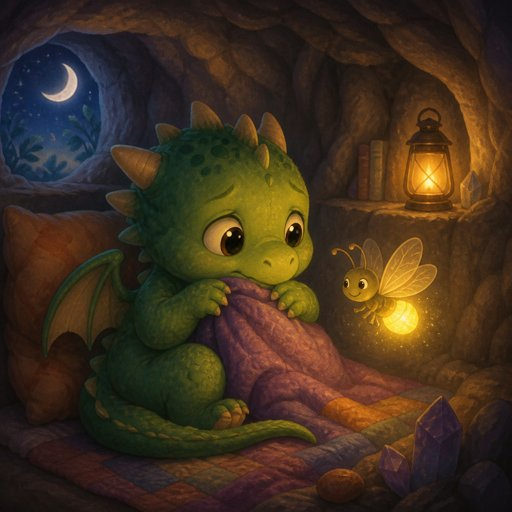

Once upon a twilight, in a cozy cave beneath Moonbeam Hill, lived a shy dragon named Dabble. Dabble could breathe silver-blue fire, but only when nobody was watching.

He was especially afraid of the dark. Each night, he hid under his blanket and whispered, “Is that a monster?”

One evening, a tiny light blinked near his nose.

“Hello,” said a firefly. “I’m Flick.”

Dabble peeked out. “Are you a monster?”

“No,” said Flick. “I’m much too small. I once got stuck in a teacup.”

Flick flew around the cave, glowing like a little star. Dabble followed, feeling braver. Soon, he showed Flick his silver-blue flame.

“Oh!” cried Flick. “You’re a walking lantern!”

Dabble giggled. Together, they explored the dark woods, lighting the way. When they returned, Dabble was no longer afraid.

From then on, Flick slept beside Dabble’s pillow, and Dabble warmed Flick’s tiny wings.

And if the darkness ever growled, Dabble simply said, “Good evening. I have a friend.”

In [19]:
import base64
from IPython.display import Image, display, Markdown

picture = client.images.generate(
    model="gpt-image-2",
    prompt=f"A soft, colorful children's storybook illustration of {idea}. Cozy and warm, no text in the image.",
    size="1024x1024",
    quality="low",        # cheap and fast for a demo; "medium" or "high" for the real thing
)

import io
from PIL import Image as PILImage

png = base64.b64decode(picture.data[0].b64_json)
small = PILImage.open(io.BytesIO(png)).convert("RGB").resize((512, 512))   # keep the notebook light
buffer = io.BytesIO(); small.save(buffer, format="JPEG", quality=85)
display(Image(buffer.getvalue()))
display(Markdown(story))

### 🔍 What just happened?

Three endpoints, three media types, and the only glue is `story`, a string. Notice the picture prompt used `idea` rather than the whole story: image models want a scene description, not 150 words of plot.

### 🎯 Your turn

Set `language = "Slovak"` and a different `voice`, then run the section again. For a choose-your-own-adventure, end the story with two options and feed the child's pick back in as the next `idea`.

# 6. Ask Your Database in Plain English

Type a question like a normal person; the app writes the SQL, runs it against a real database, and hands back the answer. Same call, aimed at code instead of prose.

### The database

A tiny IT helpdesk database: two tables loaded from CSV into SQLite. Let's look at both, because the model will need to see the same thing.

In [20]:
import sqlite3
import pandas as pd

tables = {
    "tickets": pd.read_csv("data/tickets.csv"),
    "technicians": pd.read_csv("data/technicians.csv"),
}

db = sqlite3.connect(":memory:")
for name, df in tables.items():
    df.to_sql(name, db, index=False)


def show_schema(tables):
    """Print each table the way we will describe it to the model: name, columns with types, two sample rows."""
    for name, df in tables.items():
        print(f"┌─ {name} ({len(df)} rows) " + "─" * (60 - len(name)))
        for col, dtype in df.dtypes.items():
            print(f"│  {col:<22} {str(dtype)}")
        print("│  sample rows:")
        for row in df.head(2).to_dict("records"):
            print(f"│    {row}")
        print("└" + "─" * 70)


show_schema(tables)

┌─ tickets (27 rows) ─────────────────────────────────────────────────────
│  ticket_id              object
│  title                  object
│  category               object
│  priority               object
│  status                 object
│  days_ago_created       int64
│  days_ago_resolved      float64
│  assigned_to            object
│  customer_company       object
│  sample rows:
│    {'ticket_id': 'T001', 'title': 'Server outage - production environment down', 'category': 'Network Problem', 'priority': 'Critical', 'status': 'In Progress', 'days_ago_created': 1, 'days_ago_resolved': nan, 'assigned_to': 'Sarah Johnson', 'customer_company': 'SecureBank'}
│    {'ticket_id': 'T002', 'title': 'Cannot access shared drive - entire department affected', 'category': 'Access Request', 'priority': 'Critical', 'status': 'Open', 'days_ago_created': 2, 'days_ago_resolved': nan, 'assigned_to': 'Mike Chen', 'customer_company': 'TechCorp'}
└─────────────────────────────────────────────────────────

### What the model actually receives

The model cannot open our database. It only sees the text we send: a schema description plus the question. So we build that description from the tables above and print it, because this text is the whole trick.

In [21]:
schema = "\n".join(
    f"{name}({', '.join(f'{c} {t}' for c, t in df.dtypes.astype(str).items())})\n"
    f"  sample rows: {df.head(2).to_dict('records')}"
    for name, df in tables.items()
)

developer_message = (
    "Write one SQLite SELECT query that answers the question, using only these tables:\n"
    f"{schema}\n"
    "The query must start with the word SELECT (no WITH clause, no comments). "
    "Return only the SQL, no explanation, no markdown."
)

print(developer_message)

Write one SQLite SELECT query that answers the question, using only these tables:
tickets(ticket_id object, title object, category object, priority object, status object, days_ago_created int64, days_ago_resolved float64, assigned_to object, customer_company object)
  sample rows: [{'ticket_id': 'T001', 'title': 'Server outage - production environment down', 'category': 'Network Problem', 'priority': 'Critical', 'status': 'In Progress', 'days_ago_created': 1, 'days_ago_resolved': nan, 'assigned_to': 'Sarah Johnson', 'customer_company': 'SecureBank'}, {'ticket_id': 'T002', 'title': 'Cannot access shared drive - entire department affected', 'category': 'Access Request', 'priority': 'Critical', 'status': 'Open', 'days_ago_created': 2, 'days_ago_resolved': nan, 'assigned_to': 'Mike Chen', 'customer_company': 'TechCorp'}]
technicians(tech_id int64, name object, specialization object, hire_date object, availability object)
  sample rows: [{'tech_id': 1, 'name': 'John Smith', 'specialization'

### The one call, then run it

Ask, get SQL, run the SQL. The `assert` is the minimum guardrail: never run unchecked model output against a real database.

In [22]:
def ask_database(question):
    sql = client.responses.create(
        model=MODEL,
        input=[
            {"role": "developer", "content": developer_message},
            {"role": "user", "content": question},
        ],
    ).output_text.strip().strip("`").removeprefix("sql").strip()

    assert sql.upper().startswith("SELECT"), "Refusing to run a non-SELECT query"
    return sql, pd.read_sql(sql, db)


sql, result = ask_database("Which technician has resolved the most tickets?")
print(sql)
result

SELECT tech.name, COUNT(*) AS resolved_ticket_count
FROM technicians AS tech
JOIN tickets AS t
  ON t.assigned_to = tech.name
WHERE t.days_ago_resolved IS NOT NULL
GROUP BY tech.tech_id, tech.name
ORDER BY resolved_ticket_count DESC
LIMIT 1;


,name,resolved_ticket_count
0,John Smith,3


### Three questions, three shapes of SQL

One table, a join across both tables, an aggregate. The code does not change; the model writes different SQL each time.

In [23]:
questions = [
    "How many tickets are still open, by priority?",
    "List the critical tickets with the specialization of the technician assigned to them.",
    "What is the average number of days it took each technician to resolve their tickets?",
]

for q in questions:
    sql, result = ask_database(q)
    print(f"❓ {q}\n{sql}\n")
    print(result.to_string(index=False), "\n" + "─" * 70)

❓ How many tickets are still open, by priority?
SELECT priority, COUNT(*) AS open_ticket_count
FROM tickets
WHERE status IN ('Open', 'In Progress')
GROUP BY priority;

priority  open_ticket_count
Critical                  2
    High                  3
     Low                  2
  Medium                  6 
──────────────────────────────────────────────────────────────────────
❓ List the critical tickets with the specialization of the technician assigned to them.
SELECT
  t.ticket_id,
  t.title,
  t.category,
  t.priority,
  t.status,
  t.assigned_to,
  tech.specialization
FROM tickets AS t
JOIN technicians AS tech
  ON t.assigned_to = tech.name
WHERE t.priority = 'Critical';

ticket_id                                                   title        category priority      status   assigned_to specialization
     T001             Server outage - production environment down Network Problem Critical In Progress Sarah Johnson        Network
     T002 Cannot access shared drive - entire depa

### Explain the answer back

A table is fine for us; a customer wants a sentence. One more call turns the result into plain English.

In [24]:
question = "Which customer company has the most open tickets right now?"
sql, result = ask_database(question)

answer = client.responses.create(
    model=MODEL,
    input=f"Question: {question}\nQuery result: {result.to_dict('records')}\nAnswer the question in one friendly sentence.",
).output_text

print(sql, "\n")
print(answer)

SELECT customer_company, COUNT(*) AS open_ticket_count
FROM tickets
WHERE status = 'Open'
GROUP BY customer_company
ORDER BY open_ticket_count DESC
LIMIT 1; 

TechCorp has the most open tickets right now, with 3.


### 🔍 What just happened?

The model never touched the database. It read a text description of two tables and wrote SQL; Python ran it. That split (model proposes, your code executes) is the safe pattern for anything that touches real systems, and the function-calling notebook builds on exactly this idea.

### 🎯 Your turn

Ask a question that needs both tables, then one that cannot be answered from these columns, and watch what the model does. Then point `tables` at your own CSVs.

# 7. Ticket to Knowledge-Base Article

Raw technician notes become a polished article the whole team can search, a one-line customer update, and a Slack post. One input, three developer messages.

### The one thing you change

Rough, technician-style ticket notes from the data folder. Change the file, re-run below, and you get a brand new article.

In [25]:
ticket_notes = open("data/kb_ticket_notes.txt").read()
print(ticket_notes)

Ticket #482 - Password reset link not arriving
User: sarah.chen@company.com
Notes: user says reset email never arrives, checked spam folder, tried 3x,
using Chrome, account not locked. Fix: manually triggered reset from admin
panel, email arrived within 1 min. Root cause: user's inbox rule was
routing mail from IT to a folder she never checks. Told user to review
her "IT Notifications" filter rule.



### The one call

One call turns rough notes into a clean article. Everything after this just repurposes the text it returns.

In [26]:
from IPython.display import Markdown

article = client.responses.create(
    model=MODEL,
    input=[
        {"role": "developer", "content":
            "You turn raw IT support ticket notes into a short knowledge base article for other technicians. "
            "Include a title, a one-line summary, and numbered steps. Plain markdown, about 150 words."},
        {"role": "user", "content": f"Ticket notes:\n{ticket_notes}"},
    ],
).output_text

Markdown(article)

# Password Reset Email Not Received

**Summary:** If a user does not receive a password reset email, verify inbox rules and manually resend the reset from the admin panel.

1. Confirm the user entered the correct account email address and check whether the account is locked.
2. Ask the user to check spam, junk, quarantine, and any custom folders.
3. Review inbox rules or filters for messages from IT, identity services, or the password management system. In this case, an “IT Notifications” rule routed the reset email to a folder the user did not monitor.
4. If the message is still missing, manually trigger a password reset from the administration panel.
5. Confirm that the user receives the new email, typically within one minute.
6. Ask the user to update or remove the filtering rule so future security and account notifications remain visible.
7. Document the issue and resolution in the ticket, including the affected rule and confirmation that the reset email was delivered.

### Repurpose it twice

Same article in, two different audiences out. Only the developer message changes.

In [27]:
def repurpose(instruction, text):
    return client.responses.create(
        model=MODEL,
        input=[{"role": "developer", "content": instruction}, {"role": "user", "content": text}],
    ).output_text


status_update = repurpose(
    "Write a one-line, reassuring status page update for customers, based on this internal article. "
    "No jargon, no internal details.", article)

slack_post = repurpose(
    "Write a three-bullet Slack message for the IT team summarizing this article: what happened, "
    "the fix, what to tell users. Casual tone, no headings.", article)

print("STATUS PAGE:\n", status_update, "\n")
print("SLACK:\n", slack_post)

STATUS PAGE:
 We’re helping restore password reset emails—please check your spam or email folders, and we’ll resend the message if needed. 

SLACK:
 - A user didn’t receive a password reset email because an “IT Notifications” inbox rule routed it to an unmonitored folder.
- Verify the account email and lock status, check spam/quarantine/custom folders and inbox rules, then manually resend the reset from the admin panel if needed. Confirm delivery within about a minute.
- Tell users to update or remove filters that hide IT/security emails, and document the affected rule and successful delivery in the ticket.


### 🔍 What just happened?

The article was written once and then re-shaped twice without anyone re-reading the ticket. In a real helpdesk this runs on every closed ticket, and the knowledge base writes itself.

### 🎯 Your turn

Edit `data/kb_ticket_notes.txt` (or paste other notes into `ticket_notes`) and re-run. Then add a fourth format: an email to the affected user.

# Where This Leads

Seven apps, one call shape. The rest of the course adds the concepts that turn these toys into products: grounding answers in your own documents (RAG), guaranteed output shapes (structured outputs), letting the model call your functions (function calling), and the built-in tools OpenAI hosts for you.